# Objetivo do trabalho
Uso do ResNet50 para detecção de cancer de intestino
- Dateset: DykeF/NCTCRCHE100K
- 100K imagens de treinamento e 7180 para teste
- resolução transformadas: 224 x 224 pixeis

In [1]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import seaborn as sns
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA A100-SXM4-40GB
CUDA: 12.6


In [4]:
!pip install -q datasets==2.14.6

In [6]:
from datasets import load_dataset
ds = load_dataset("DykeF/NCTCRCHE100K")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train_nonorm split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'file'],
        num_rows: 100000
    })
    train_nonorm: Dataset({
        features: ['image', 'label', 'file'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['image', 'label', 'file'],
        num_rows: 7180
    })
})

In [8]:
splited = ds["train"].train_test_split(test_size=0.2, seed=42)
dataset_train = splited["train"]
dataset_validation = splited["test"]
dataset_test = ds["validation"]

In [9]:
set(dataset_train["label"])

{'ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM'}

In [10]:
cancer_classes = {"TUM"}
normal_classes = {"ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR"}

In [11]:

print(f"\nNumber of images in training dataset: {len(dataset_train)}")
print(f"Number of images in validation dataset: {len(dataset_validation)}")
print(f"Number of images in test dataset: {len(dataset_test)}")


Number of images in training dataset: 80000
Number of images in validation dataset: 20000
Number of images in test dataset: 7180


In [12]:
def to_binary(example):
    if example["label"] == "TUM":
        example["label"] = 1
    else:
        example["label"] = 0
    return example

dataset_train = dataset_train.map(to_binary)
dataset_validation = dataset_validation.map(to_binary)
dataset_test = dataset_test.map(to_binary)

print(f"\nNumber of images in training dataset: {len(dataset_train)}")
print(f"Number of images in validation dataset: {len(dataset_validation)}")
print(f"Number of images in test dataset: {len(dataset_test)}")


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7180 [00:00<?, ? examples/s]


Number of images in training dataset: 80000
Number of images in validation dataset: 20000
Number of images in test dataset: 7180


In [13]:
set(dataset_train["label"])

{0, 1}

In [14]:
print(dataset_train.features)

{'image': Image(decode=True, id=None), 'label': Value(dtype='int64', id=None), 'file': Value(dtype='string', id=None)}


In [15]:
class NCTCRCHE100KDatasetMemory(Dataset):
    def __init__(self, hf_dataset, transforms=None):
        self.transforms = transforms

        self.images = []
        self.labels = []

        for item in hf_dataset:
            image = item["image"].convert("RGB")
            image = np.array(image)

            self.images.append(image)
            self.labels.append(item["label"])

        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transforms:
            image = self.transforms(image=image)["image"]

        return image, label
    
class CustomDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_dataloaders(df_train, df_validation, df_test, batch_size=64, num_workers=2):

    dataset_train = NCTCRCHE100KDatasetMemory(df_train, transforms=CustomDatasetConfig.TRAIN_TRANSFORMS)
    dataset_validation = NCTCRCHE100KDatasetMemory(df_validation, transforms=CustomDatasetConfig.TEST_TRANSFORMS)
    dataset_test = NCTCRCHE100KDatasetMemory(df_test, transforms=CustomDatasetConfig.TEST_TRANSFORMS)

    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=num_workers)
    val_loader = DataLoader(dataset_validation, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)
    test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)

    return train_loader, val_loader, test_loader

In [16]:
batch_size = 64
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(dataset_train, dataset_validation, dataset_test, batch_size, 2)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 0.002
- Otimizador: SGB momentum 0.9
- Weight Decay: 5*1e-4
- número de épocas: 50

In [17]:
in_channels = 3
output_features = 2
learning_rate = 1e-2
weight_decay = 5*1e-4
momentum=0.9

In [18]:
model = torchvision.models.resnet50(num_classes=output_features)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

### Treinamento

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
criterion = torch.nn.CrossEntropyLoss()

def train_model(model, dataloader_train, dataloader_validation, optimizer, epochs = 10, patience = 0, scheduler = None, drive_path = '/content/drive/MyDrive/Machine Learning/Resultados TCC/models/NCTCRCHE100K/SGD/normal/ResNet50_best.pt'):
    model = model.to("cuda")
    device = "cuda"
    train_losses = []
    val_losses = []
    best_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_loss_validation = 0

        for images, labels in dataloader_train:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size()[0]

        with torch.no_grad():
            model.eval() 

            for images, labels in dataloader_validation:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss_validation += loss.item() * images.size()[0]
            

        avg_train_loss = total_loss / len(dataloader_train.dataset)
        avg_val_loss = total_loss_validation / len(dataloader_validation.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step()

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"{model.__class__.__name__}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        if patience > 0 and epochs_no_improve >= patience:
            print(f"\nEarly stopping ativado! Melhor Val Loss: {best_loss:.4f}")
            break
    
    model.load_state_dict(best_model_state)
    os.makedirs(drive_path, exist_ok=True)
    best_path = drive_path + f"/{model.__class__.__name__}_best.pt"
    torch.save(best_model_state, best_path)
    return train_losses, val_losses, model

def test_model(model, device, dataloader_test):
    model = model.to(device)
    model.eval()  # Modo de avaliação
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Cálculo das métricas
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    print(cm)

    return acc, precision, recall, f1, cm


In [21]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 15)

Epoch 1/50 | Train Loss: 0.1606 | Val Loss: 0.0592
Epoch 2/50 | Train Loss: 0.0631 | Val Loss: 0.0877
Epoch 3/50 | Train Loss: 0.0496 | Val Loss: 0.0338
Epoch 4/50 | Train Loss: 0.0887 | Val Loss: 0.0750
Epoch 5/50 | Train Loss: 0.0643 | Val Loss: 0.0479
Epoch 6/50 | Train Loss: 0.0530 | Val Loss: 0.0398
Epoch 7/50 | Train Loss: 0.0384 | Val Loss: 0.0306
Epoch 8/50 | Train Loss: 0.0339 | Val Loss: 0.0355
Epoch 9/50 | Train Loss: 0.0300 | Val Loss: 0.0270
Epoch 10/50 | Train Loss: 0.0297 | Val Loss: 0.0272
Epoch 11/50 | Train Loss: 0.0247 | Val Loss: 0.0248
Epoch 12/50 | Train Loss: 0.0229 | Val Loss: 0.0330
Epoch 13/50 | Train Loss: 0.0195 | Val Loss: 0.0367
Epoch 14/50 | Train Loss: 0.0217 | Val Loss: 0.0305
Epoch 15/50 | Train Loss: 0.0191 | Val Loss: 0.0333
Epoch 16/50 | Train Loss: 0.0159 | Val Loss: 0.0210
Epoch 17/50 | Train Loss: 0.0154 | Val Loss: 0.0488
Epoch 18/50 | Train Loss: 0.0135 | Val Loss: 0.0192
Epoch 19/50 | Train Loss: 0.0165 | Val Loss: 0.0280
Epoch 20/50 | Train L

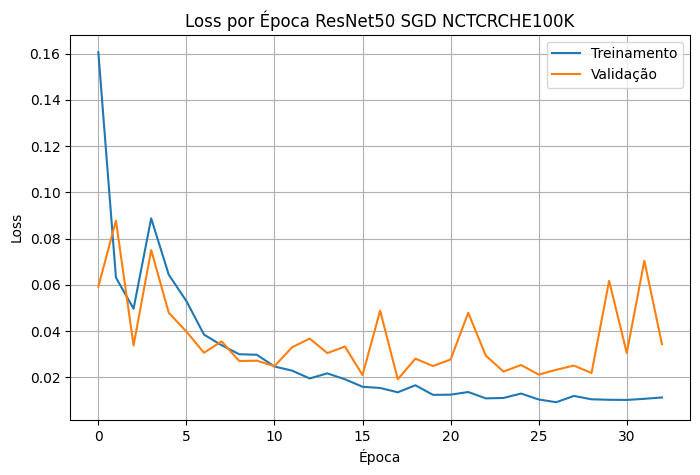

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época ResNet50 SGD NCTCRCHE100K")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.9879
Precisão (weighted): 0.9880
Recall (weighted): 0.9879
F1-score (weighted): 0.9879
Matriz de Confusão:
[[5892   55]
 [  32 1201]]


In [24]:
headers = ["Métrica ResNet50 SGD NCTCRCHE100K", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════════════════════╤═════════╕
│ Métrica ResNet50 SGD NCTCRCHE100K   │   Valor │
╞═════════════════════════════════════╪═════════╡
│ Acurácia                            │  0.9879 │
├─────────────────────────────────────┼─────────┤
│ Precisão (weighted)                 │  0.988  │
├─────────────────────────────────────┼─────────┤
│ Recall (weighted)                   │  0.9879 │
├─────────────────────────────────────┼─────────┤
│ F1-score (weighted)                 │  0.9879 │
╘═════════════════════════════════════╧═════════╛


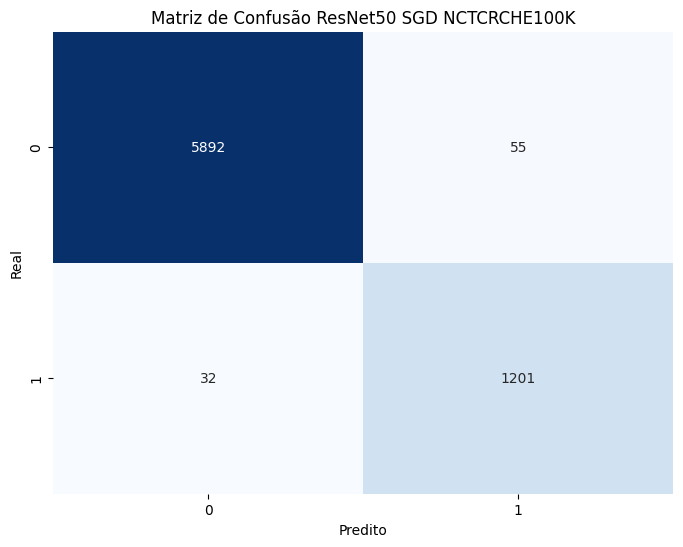

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão ResNet50 SGD NCTCRCHE100K")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## Rodando testes com diferentes DataSets
- LC25000
- CRC5000

In [26]:
batch_size = 64
output_features = 2

In [27]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
colon_image_sets  lung_image_sets


In [28]:
class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [29]:
 
path_to_dataset_lc = pathlib.Path('/content/lung_colon_image_set/colon_image_sets')
LC25000Formatter(input_path = path_to_dataset_lc, output_csv = "nb_lc25000.csv").run()
dataframe_lc = pd.read_csv("/content/nb_lc25000.csv")
df_test_lc = dataframe_lc[["path", "label"]]
print(f"Number of images in test dataset lc25000: {len(df_test_lc)}")

100%|██████████| 10002/10002 [00:00<00:00, 26035.23it/s]


CSV salvo com sucesso em: nb_lc25000.csv
Number of images in test dataset lc25000: 10000


In [30]:
class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    

class CustomDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

In [31]:
dataset_test_lc = LC25000DatasetMemory(
        df_test_lc,
        transforms=CustomDatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )
dataloader_test_lc = DataLoader(dataset_test_lc, batch_size= batch_size, pin_memory = True,shuffle= False)

In [32]:
#from google.colab import drive
#drive.mount('/content/drive')

**Atenção: apenas rode o trecho de código abaixo caso não esteja rodando o notebook todo de uma vez**

In [33]:
#model = torchvision.models.resnet50(num_classes=output_features)
#path = "/content/drive/MyDrive/Machine Learning/Resultados TCC/models/NCTCRCHE100K/SGD/normal/ResNet50_best.pt"
#model.load_state_dict(torch.load(path, map_location="cuda"))

In [34]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test_lc)

Acurácia: 0.5000
Precisão (weighted): 0.2500
Recall (weighted): 0.5000
F1-score (weighted): 0.3333
Matriz de Confusão:
[[5000    0]
 [5000    0]]


In [35]:
headers = ["Métrica ResNet50 SGD LC25000", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒════════════════════════════════╤═════════╕
│ Métrica ResNet50 SGD LC25000   │   Valor │
╞════════════════════════════════╪═════════╡
│ Acurácia                       │  0.5    │
├────────────────────────────────┼─────────┤
│ Precisão (weighted)            │  0.25   │
├────────────────────────────────┼─────────┤
│ Recall (weighted)              │  0.5    │
├────────────────────────────────┼─────────┤
│ F1-score (weighted)            │  0.3333 │
╘════════════════════════════════╧═════════╛


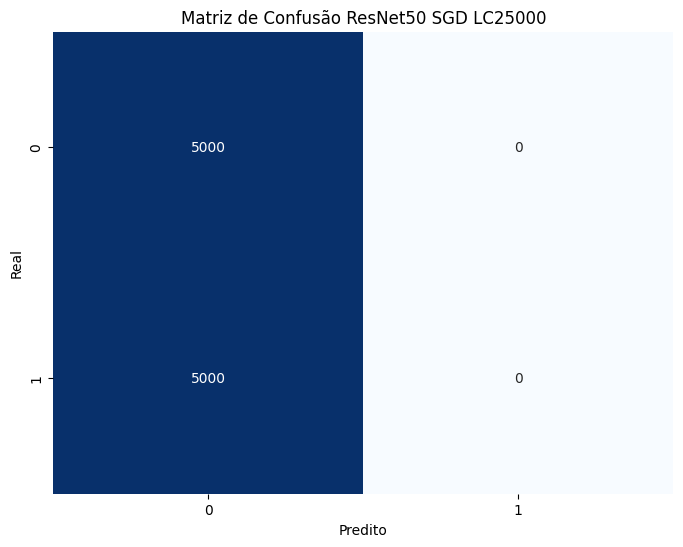

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão ResNet50 SGD LC25000")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [37]:

path = kagglehub.dataset_download("kmader/colorectal-histology-mnist")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000


Using Colab cache for faster access to the 'colorectal-histology-mnist' dataset.
01_TUMOR   03_COMPLEX  05_DEBRIS  07_ADIPOSE
02_STROMA  04_LYMPHO   06_MUCOSA  08_EMPTY


In [38]:
class CRC5000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "01_TUMOR": int(1),
            "02_STROMA": int(0),
            "03_COMPLEX": int(0),
            "04_LYMPHO": int(0),
            "05_DEBRIS": int(0),
            "06_MUCOSA": int(0),
            "07_ADIPOSE": int(0),
            "08_EMPTY": int(0),
        }
        image_extensions = ['.tif', '.tiff']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                if label not in label_map:
                    continue
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df
    

In [39]:
path_to_dataset_crc = pathlib.Path('/content/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000')
CRC5000Formatter(input_path = path_to_dataset_crc, output_csv = "nb_crc5000.csv").run()
dataframe_crc = pd.read_csv("/content/nb_crc5000.csv")
df_test_crc = dataframe_crc[["path", "label"]]
print(f"Number of images in test dataset crc5000: {len(df_test_crc)}")

100%|██████████| 5008/5008 [00:00<00:00, 25664.86it/s]


CSV salvo com sucesso em: nb_crc5000.csv
Number of images in test dataset crc5000: 5000


In [40]:
class CRC5000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [41]:
dataset_test_crc = CRC5000DatasetMemory(
        df_test_crc,
        transforms=CustomDatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )
dataloader_test_crc = DataLoader(dataset_test_crc, batch_size= batch_size, pin_memory = True,shuffle= False)

In [42]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test_crc)

Acurácia: 0.8640
Precisão (weighted): 0.7644
Recall (weighted): 0.8640
F1-score (weighted): 0.8112
Matriz de Confusão:
[[4320   55]
 [ 625    0]]


In [43]:
headers = ["Métrica ResNet50 SGD CRC5000", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒════════════════════════════════╤═════════╕
│ Métrica ResNet50 SGD CRC5000   │   Valor │
╞════════════════════════════════╪═════════╡
│ Acurácia                       │  0.864  │
├────────────────────────────────┼─────────┤
│ Precisão (weighted)            │  0.7644 │
├────────────────────────────────┼─────────┤
│ Recall (weighted)              │  0.864  │
├────────────────────────────────┼─────────┤
│ F1-score (weighted)            │  0.8112 │
╘════════════════════════════════╧═════════╛


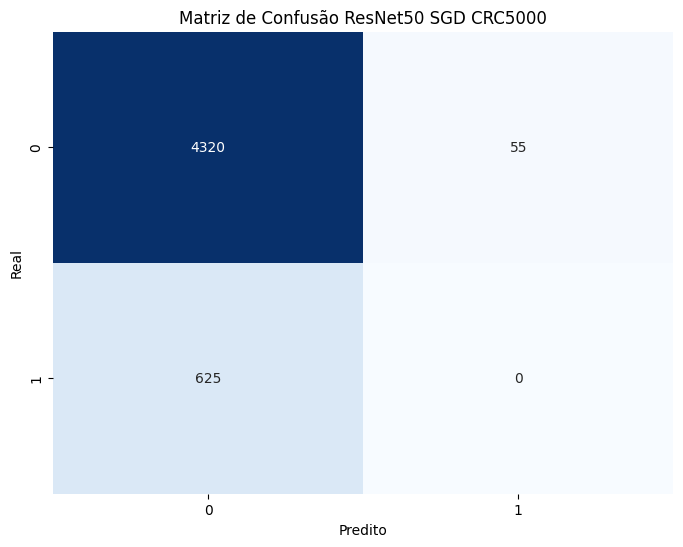

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão ResNet50 SGD CRC5000")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()